# Hei Njål
# ***I LOVE COCK***

In [8]:
print('U lost bbygurl?')

U lost bbygurl?


Importing required libraries and our dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

import seaborn as sns



df = pd.read_csv("../data/england-premier-league-matches-2018-to-2019-stats.csv")

c:\Users\sande\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analyszing features

In [2]:
df.head()
# Identify odds-related columns
odds_columns = [col for col in df.columns if 'odds' in col.lower()]

# Identify pre-match columns
prematch_columns = [col for col in df.columns if 'pre' in col.lower() and 'match' in col.lower()]

# Remove columns with all null values
null_columns = [col for col in df.columns if (df[col] == 0).all()]

# Remove incomplete matches (if any)
not_completed = [col for col in df.columns if (df['status'] != 'complete').any()]



Data cleaning

In [3]:

#Remove all columns in the dataset that include odds. 
df_filtered = df.drop(columns = odds_columns)

# The first match 2 matches of the season has no 'pre-match' content, but are valued at 0, which could mess with this feature
df_filtered.loc[df['Game Week'] <= 2, prematch_columns] = np.nan

# Parse date_GMT into useful features
df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')
df_filtered['match_month'] = df_filtered['match_date'].dt.month
df_filtered['match_day'] = df_filtered['match_date'].dt.day
df_filtered['match_weekday'] = df_filtered['match_date'].dt.weekday
df_filtered = df_filtered.drop(columns=['date_GMT', 'match_date'])


# Drop Irrelevant or Redundant Columns
df_filtered = df_filtered.drop(columns=['status', 'home_team_goal_timings', 'away_team_goal_timings',
                                        'total_goal_count', 'home_team_goal_count_half_time',
                                        'away_team_goal_count_half_time', 'total_goals_at_half_time'])


# Label encode categorical columns after handling missing values
categorical_columns = ['home_team_name', 'away_team_name', 'stadium_name', 'referee']

# Encode Categorical Columns
categorical_columns = ['home_team_name', 'away_team_name', 'stadium_name', 'referee']
label_encoders = {}
for col in categorical_columns:
    df_filtered[col] = df_filtered[col].fillna("Unknown")
    le = LabelEncoder()
    df_filtered[col] = le.fit_transform(df_filtered[col].astype(str))
    label_encoders[col] = le


# Fill missing values only for numeric columns
numeric_columns = df_filtered.select_dtypes(include=[np.number]).columns
df_filtered[numeric_columns] = df_filtered[numeric_columns].fillna(df_filtered[numeric_columns].mean())

df_filtered.sample(5)

C:\Users\sande\AppData\Local\Temp\ipykernel_30020\1006613958.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')


,timestamp,attendance,home_team_name,away_team_name,referee,Game Week,Pre-Match PPG (Home),Pre-Match PPG (Away),home_ppg,away_ppg,...,over_15_HT_FHG_percentage_pre_match,over_05_HT_FHG_percentage_pre_match,over_15_2HG_percentage_pre_match,over_05_2HG_percentage_pre_match,average_corners_per_match_pre_match,average_cards_per_match_pre_match,stadium_name,match_month,match_day,match_weekday
250,1549482300,39322,7,12,4,27,1.62,1.92,1.79,2.32,...,44.0,73.0,44.0,80.0,13.81,3.38,5,2,6,2
369,1557169200,54506,12,10,13,37,2.83,1.39,2.84,1.32,...,42.0,84.0,53.0,89.0,13.61,2.34,4,5,6,0
114,1541862000,28153,15,17,16,12,0.60,1.40,1.21,1.21,...,20.0,50.0,50.0,70.0,11.40,4.40,13,11,10,5
23,1535205600,21193,9,4,12,3,0.00,0.00,0.47,0.74,...,50.0,100.0,0.0,100.0,6.00,3.00,6,8,25,5
238,1548878400,53092,11,10,11,24,2.82,1.42,2.79,1.32,...,31.0,75.0,44.0,83.0,13.01,2.58,0,1,30,2


#### Feature Importance Testing
First we will see how the features correlates to get an idea:


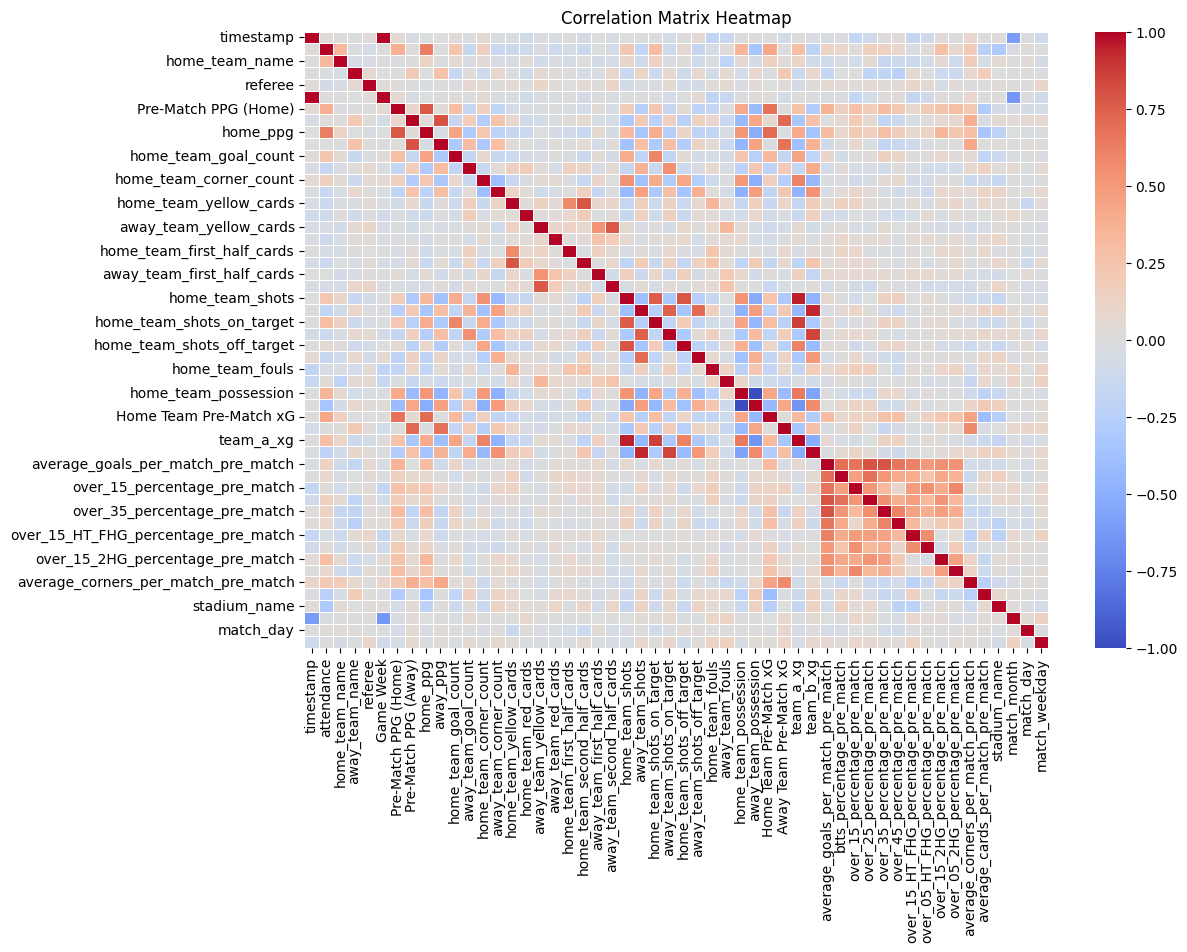

In [4]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df_filtered.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Then, using the *Random Forest Regressor* we will find the feature importance


--- Home Team Scores ---
Mean Absolute Error (MAE): 0.9356578947368421
Mean Squared Error (MSE): 1.314196052631579
R^2 Score: 0.15732722024866774

--- Away Team Scores ---
Mean Absolute Error (MAE): 0.6878947368421052
Mean Squared Error (MSE): 0.8132473684210527
R^2 Score: 0.21396974564926363


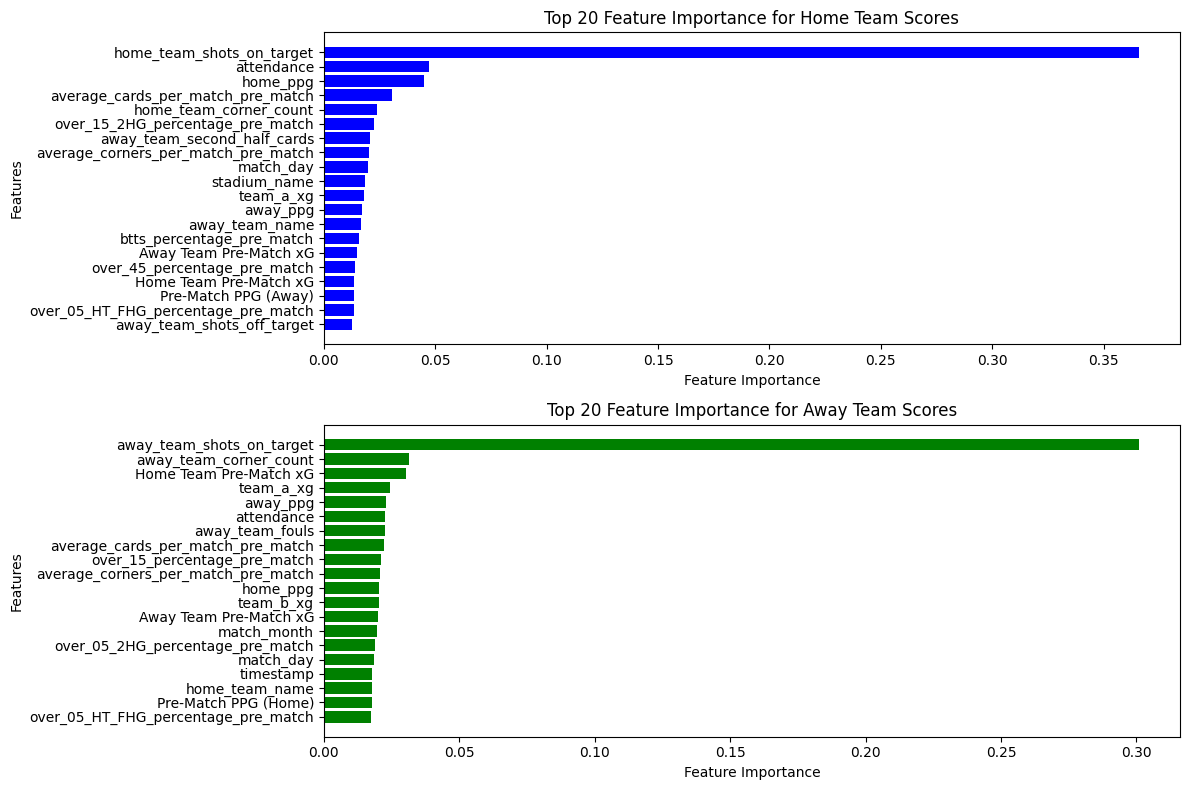

In [7]:
# Define feature and target columns
target_columns = ['home_team_goal_count', 'away_team_goal_count']
X = df_filtered.drop(columns=target_columns)
y_home = df_filtered['home_team_goal_count']
y_away = df_filtered['away_team_goal_count']

# Split dataset into train-test sets for home and away scores
X_train_home, X_test_home, y_train_home, y_test_home = train_test_split(X, y_home, test_size=0.2, random_state=42)
X_train_away, X_test_away, y_train_away, y_test_away = train_test_split(X, y_away, test_size=0.2, random_state=42)

# Train Random Forest models for home and away scores
rf_home = RandomForestRegressor(random_state=42)
rf_home.fit(X_train_home, y_train_home)

rf_away = RandomForestRegressor(random_state=42)
rf_away.fit(X_train_away, y_train_away)

# Extract feature importance for home and away scores
importances_home = rf_home.feature_importances_
importances_away = rf_away.feature_importances_

feature_importance_home_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_home})
feature_importance_away_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_away})

feature_importance_home_df.sort_values(by='Importance', ascending=False, inplace=True)
feature_importance_away_df.sort_values(by='Importance', ascending=False, inplace=True)

# Evaluate models on test data
y_pred_home = rf_home.predict(X_test_home)
y_pred_away = rf_away.predict(X_test_away)

# Metrics for Home Scores
print("\n--- Home Team Scores ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home)}")

# Metrics for Away Scores
print("\n--- Away Team Scores ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away)}")

# Visualize Top Features
top_n = 20  # Number of features to display
top_features_home = feature_importance_home_df.head(top_n)
top_features_away = feature_importance_away_df.head(top_n)

# Top features home team
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.barh(top_features_home['Feature'], top_features_home['Importance'], color='blue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Home Team Scores')
plt.gca().invert_yaxis()

# Top features away team
plt.subplot(2, 1, 2)
plt.barh(top_features_away['Feature'], top_features_away['Importance'], color='green')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Away Team Scores')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Then we use *Recursive Feature Elimination* to select which features to carry on using. We will then have a list of features optimized for each score. We will use this to make better models, one for each score, and then we will try a MultiRegressor to compare how they perform.

In [6]:
# Recursive Feature Elimination (RFE) for Home Team Scores
rfe_home = RFE(estimator=rf_home, n_features_to_select=10)
rfe_home.fit(X_train_home, y_train_home)
selected_features_home = X.columns[rfe_home.support_]

# Recursive Feature Elimination (RFE) for Away Team Scores
rfe_away = RFE(estimator=rf_away, n_features_to_select=10)
rfe_away.fit(X_train_away, y_train_away)
selected_features_away = X.columns[rfe_away.support_]

# Print selected features
print("Selected Features for Home Team Scores using RFE:", selected_features_home)
print("Selected Features for Away Team Scores using RFE:", selected_features_away)

# Train New Models on RFE-Selected Features
rf_home_rfe = RandomForestRegressor(random_state=42)
rf_away_rfe = RandomForestRegressor(random_state=42)

rf_home_rfe.fit(X_train_home[selected_features_home], y_train_home)
rf_away_rfe.fit(X_train_away[selected_features_away], y_train_away)

# Predictions with RFE-Selected Features
y_pred_home_rfe = rf_home_rfe.predict(X_test_home[selected_features_home])
y_pred_away_rfe = rf_away_rfe.predict(X_test_away[selected_features_away])

# Evaluate RFE Models
print("\n--- Home Team Scores (RFE Model) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_rfe)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_rfe)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_rfe)}")

print("\n--- Away Team Scores (RFE Model) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_rfe)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_rfe)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_rfe)}")



Selected Features for Home Team Scores using RFE: Index(['attendance', 'home_ppg', 'away_ppg', 'home_team_corner_count',
       'home_team_shots_on_target', 'team_a_xg', 'team_b_xg',
       'over_15_2HG_percentage_pre_match',
       'average_corners_per_match_pre_match',
       'average_cards_per_match_pre_match'],
      dtype='object')
Selected Features for Away Team Scores using RFE: Index(['timestamp', 'attendance', 'away_team_shots_on_target',
       'away_team_fouls', 'away_team_possession', 'Home Team Pre-Match xG',
       'team_a_xg', 'over_15_percentage_pre_match',
       'average_corners_per_match_pre_match',
       'average_cards_per_match_pre_match'],
      dtype='object')

--- Home Team Scores (RFE Model) ---
Mean Absolute Error (MAE): 0.9018421052631578
Mean Squared Error (MSE): 1.2960763157894735
R^2 Score: 0.16894573712255778

--- Away Team Scores (RFE Model) ---
Mean Absolute Error (MAE): 0.7478947368421052
Mean Squared Error (MSE): 0.9504605263157895
R^2 Score: 0.08134

Now using these found *optimal* features to teste the precision of the **Random Forest Regressor* model:

In [8]:
# # Use RFE-selected features for test data
# X_test_home_rfe = X_test_home[selected_features_home]
# X_test_away_rfe = X_test_away[selected_features_away]
# Align test data to training feature names for home team
X_test_home_rfe_aligned = X_test_home.reindex(columns=X_train_home.columns, fill_value=0)

# Align test data to training feature names for away team
X_test_away_rfe_aligned = X_test_away.reindex(columns=X_train_away.columns, fill_value=0)

# Predict using RFE-selected features
y_pred_home_rfe = rf_home.predict(X_test_home_rfe_aligned)
y_pred_away_rfe = rf_away.predict(X_test_away_rfe_aligned)

# Metrics for Home Scores (RFE-Selected Features)
print("\n--- Home Team Scores (RFE Selected Features) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_rfe)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_rfe)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_rfe)}")

# Metrics for Away Scores (RFE-Selected Features)
print("\n--- Away Team Scores (RFE Selected Features) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_rfe)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_rfe)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_rfe)}")



--- Home Team Scores (RFE Selected Features) ---
Mean Absolute Error (MAE): 0.9356578947368421
Mean Squared Error (MSE): 1.314196052631579
R^2 Score: 0.15732722024866774

--- Away Team Scores (RFE Selected Features) ---
Mean Absolute Error (MAE): 0.6878947368421052
Mean Squared Error (MSE): 0.8132473684210527
R^2 Score: 0.21396974564926363


#### Visualizing the difference in the **Random Forest Regressor* models with and without **RFE** features:

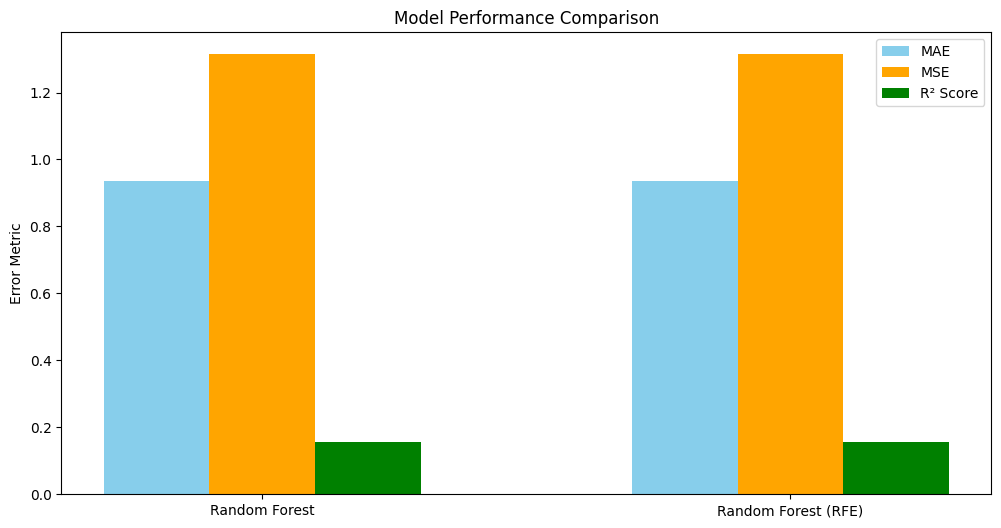

In [9]:
# Visualize Comparison of Models
models = ['Random Forest', 'Random Forest (RFE)']
mae = [
    mean_absolute_error(y_test_home, rf_home.predict(X_test_home)),
    mean_absolute_error(y_test_home, y_pred_home_rfe)
]
mse = [
    mean_squared_error(y_test_home, rf_home.predict(X_test_home)),
    mean_squared_error(y_test_home, y_pred_home_rfe)
]
r2 = [
    r2_score(y_test_home, rf_home.predict(X_test_home)),
    r2_score(y_test_home, y_pred_home_rfe)
]

x = np.arange(len(models))

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, mae, 0.2, label='MAE', color='skyblue')
plt.bar(x, mse, 0.2, label='MSE', color='orange')
plt.bar(x + 0.2, r2, 0.2, label='R² Score', color='green')

plt.xticks(x, models)
plt.ylabel('Error Metric')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

### Using Gradient Boosting for Improved Performance
Gradient Boosting methods like XGBoost (eXtreme Gradient Boosting) often outperform Random Forest for structured/tabular data because:

- It optimizes each decision tree sequentially to reduce errors.
- It provides finer control over regularization and learning rates.

XGBoost is a machine learning algorithm based on gradient boosting, which builds decision trees sequentially to correct errors made by previous trees. It’s known for its speed, accuracy, and scalability.
- Boosting: Combines multiple weak models (trees) into a strong model.
- Gradient Descent: Optimizes the model by minimizing a loss function (e.g., Mean Squared Error).
- Regularization: Prevents overfitting using techniques like gamma and lambda.
- Efficiency: Parallel processing and optimized memory usage make it fast and scalable.
- High performance for structured/tabular data.
- Flexibility to handle regression, classification, and ranking tasks.
- Handles missing values automatically.

In [10]:
# Use RFE-selected features
X_train_home_rfe = X_train_home[selected_features_home]
X_test_home_rfe = X_test_home[selected_features_home]

X_train_away_rfe = X_train_away[selected_features_away]
X_test_away_rfe = X_test_away[selected_features_away]

# Initialize XGBoost models
xgb_home = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_away = XGBRegressor(objective='reg:squarederror', random_state=42)

# Train models
xgb_home.fit(X_train_home_rfe, y_train_home)
xgb_away.fit(X_train_away_rfe, y_train_away)

# Make predictions
y_pred_home_xgb = xgb_home.predict(X_test_home_rfe)
y_pred_away_xgb = xgb_away.predict(X_test_away_rfe)

# Evaluate models
print("\n--- Home Team Scores (XGBoost) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_xgb)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_xgb)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_xgb)}")

print("\n--- Away Team Scores (XGBoost) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_xgb)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_xgb)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_xgb)}")




--- Home Team Scores (XGBoost) ---
Mean Absolute Error (MAE): 0.8328395485877991
Mean Squared Error (MSE): 1.1648461818695068
R^2 Score: 0.2530915141105652

--- Away Team Scores (XGBoost) ---
Mean Absolute Error (MAE): 0.8520874381065369
Mean Squared Error (MSE): 1.2961058616638184
R^2 Score: -0.25272881984710693


## Hyper Parameter + XGBoost

#### XGBoost
- XGBoost handles both numerical features and large datasets efficiently.
- Tuning ensures the model balances accuracy and generalization.
- Results are often superior to untuned models, as hyperparameters like learning_rate and max_depth are key to performance.

#### Hyper Parameter Tuning
- Improve Accuracy: Tuning ensures the model makes more accurate score predictions by finding the best combination of parameters.
- Prevent Overfitting: Optimized parameters help the model generalize better to unseen matches.
- Model Efficiency: Avoid unnecessary complexity and reduce computational time with optimal hyperparameter choices.


In [14]:
# # Define the hyperparameter grid
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'subsample': [0.8, 1.0],
#     'min_child_weight': [1, 3, 5]
# }

# Use RFE-selected features
# X_train_home_rfe = X_train_home[selected_features_home]
# X_test_home_rfe = X_test_home[selected_features_home]

# # Initialize the XGBoost model
# xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# # Grid Search with 3-fold cross-validation
# grid_search_home = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )

# # Fit Grid Search for Home Team Scores
# grid_search_home.fit(X_train_home_rfe, y_train_home)

# # Best parameters and model
# print("Best Parameters for Home Team Scores:", grid_search_home.best_params_)
# best_xgb_home = grid_search_home.best_estimator_

# random_search_home = RandomizedSearchCV(
#     estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
#     param_distributions=param_grid,
#     n_iter=50,  # Number of random combinations to try
#     scoring='neg_mean_squared_error',
#     cv=5,  # Use more folds for better generalization
#     verbose=1,
#     n_jobs=-1
# )
# random_search_home.fit(X_train_home_rfe, y_train_home)
# print("Best Parameters from Randomized Search:", random_search_home.best_params_)


# # Predictions and eavluation with tuned XGBoost for Home Team Scores
# y_pred_home_tuned = best_xgb_home.predict(X_test_home_rfe)
# print("Tuned XGBoost Results for Home Team Scores:")
# print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_tuned)}")
# print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_tuned)}")
# print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_tuned)}")


# # Fit Grid Search for Away Team Scores
# X_train_away_rfe = X_train_away[selected_features_away]
# X_test_away_rfe = X_test_away[selected_features_away]

# grid_search_away = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )

# grid_search_away.fit(X_train_away_rfe, y_train_away)

# # Best parameters and evaluation
# # print("Best Parameters for Away Team Scores:", grid_search_away.best_params_)
# best_xgb_away = grid_search_away.best_estimator_

# # Prediction and evaluation with tuned XGBoost for Away Team Scores
# y_pred_away_tuned = best_xgb_away.predict(X_test_away_rfe)
# print("Tuned XGBoost Results for Away Team Scores:")
# print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_tuned)}")
# print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_tuned)}")
# print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_tuned)}")

# from bayes_opt import BayesianOptimization
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from xgboost import XGBRegressor

# # Define the function to optimize
# def xgb_evaluate(n_estimators, max_depth, learning_rate, subsample, min_child_weight):
#     # Convert float inputs to integers where necessary
#     n_estimators = int(n_estimators)
#     max_depth = int(max_depth)
    
#     # Initialize XGBoost model with given parameters
#     xgb_model = XGBRegressor(
#         objective='reg:squarederror',
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         learning_rate=learning_rate,
#         subsample=subsample,
#         min_child_weight=min_child_weight,
#         random_state=42
#     )
    
#     # Fit model
#     xgb_model.fit(X_train_home_rfe, y_train_home)
    
#     # Make predictions and calculate MSE
#     y_pred = xgb_model.predict(X_test_home_rfe)
#     mse = mean_squared_error(y_test_home, y_pred)
    
#     # Return the negative MSE (Bayesian optimization maximizes a function, so we negate the error)
#     return -mse

# # Define the hyperparameter space for optimization
# param_bounds = {
#     'n_estimators': (50, 200),           # Number of estimators
#     'max_depth': (2, 6),                 # Maximum depth of the trees
#     'learning_rate': (0.01, 0.2),        # Learning rate
#     'subsample': (0.6, 1.0),             # Subsample ratio of the training instances
#     'min_child_weight': (1, 5)           # Minimum sum of instance weight (hessian) needed in a child
# }

# # Initialize Bayesian Optimization
# optimizer = BayesianOptimization(
#     f=xgb_evaluate,
#     pbounds=param_bounds,
#     random_state=42,
#     verbose=2
# )

# # Perform optimization
# optimizer.maximize(
#     init_points=5,    # Number of random points to evaluate initially
#     n_iter=20         # Number of optimization steps
# )

# # Get the best parameters
# best_params = optimizer.max['params']
# best_params['n_estimators'] = int(best_params['n_estimators'])  # Convert to integer
# best_params['max_depth'] = int(best_params['max_depth'])        # Convert to integer
# print("\nBest Parameters Found:", best_params)

# # Train the final XGBoost model with the best parameters
# xgb_best = XGBRegressor(
#     objective='reg:squarederror',
#     n_estimators=best_params['n_estimators'],
#     max_depth=best_params['max_depth'],
#     learning_rate=best_params['learning_rate'],
#     subsample=best_params['subsample'],
#     min_child_weight=best_params['min_child_weight'],
#     random_state=42
# )
# xgb_best.fit(X_train_home_rfe, y_train_home)

# # Make predictions and evaluate the optimized model
# y_pred_home_tuned = xgb_best.predict(X_test_home_rfe)
# print("\n--- Home Team Scores (XGBoost - Bayesian Tuned) ---")
# print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_tuned):.4f}")
# print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_tuned):.4f}")
# print(f"R² Score: {r2_score(y_test_home, y_pred_home_tuned):.4f}")




# Define the objective function for optimization
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
    }
    model = XGBRegressor(objective='reg:squarederror', random_state=42, **params)
    model.fit(X_train_home_rfe, y_train_home)
    y_pred = model.predict(X_test_home_rfe)
    return mean_squared_error(y_test_home, y_pred)

# Run the optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Best parameters
# print("Best parameters:", study.best_params)

# Train final XGBoost model with best parameters from Optuna
best_params = study.best_params
final_xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)
final_xgb_model.fit(X_train_home_rfe, y_train_home)

# Make predictions
y_pred_home_optuna = final_xgb_model.predict(X_test_home_rfe)




[I 2024-12-19 17:15:41,678] A new study created in memory with name: no-name-22f7ef32-7aa1-499c-b0a9-b85688e30c13
[I 2024-12-19 17:15:41,752] Trial 0 finished with value: 1.308501958847046 and parameters: {'n_estimators': 124, 'max_depth': 5, 'learning_rate': 0.02848871433524435, 'subsample': 0.8980362253115335, 'min_child_weight': 3}. Best is trial 0 with value: 1.308501958847046.
[I 2024-12-19 17:15:41,844] Trial 1 finished with value: 1.3065983057022095 and parameters: {'n_estimators': 192, 'max_depth': 5, 'learning_rate': 0.15943501892228928, 'subsample': 0.9813015607308782, 'min_child_weight': 2}. Best is trial 1 with value: 1.3065983057022095.
[I 2024-12-19 17:15:41,897] Trial 2 finished with value: 1.3643814325332642 and parameters: {'n_estimators': 148, 'max_depth': 2, 'learning_rate': 0.13367604313924025, 'subsample': 0.6903650701641856, 'min_child_weight': 2}. Best is trial 1 with value: 1.3065983057022095.
[I 2024-12-19 17:15:41,960] Trial 3 finished with value: 1.3373912572

### Comparing XGBoost with and without tuning Hyper Parameters

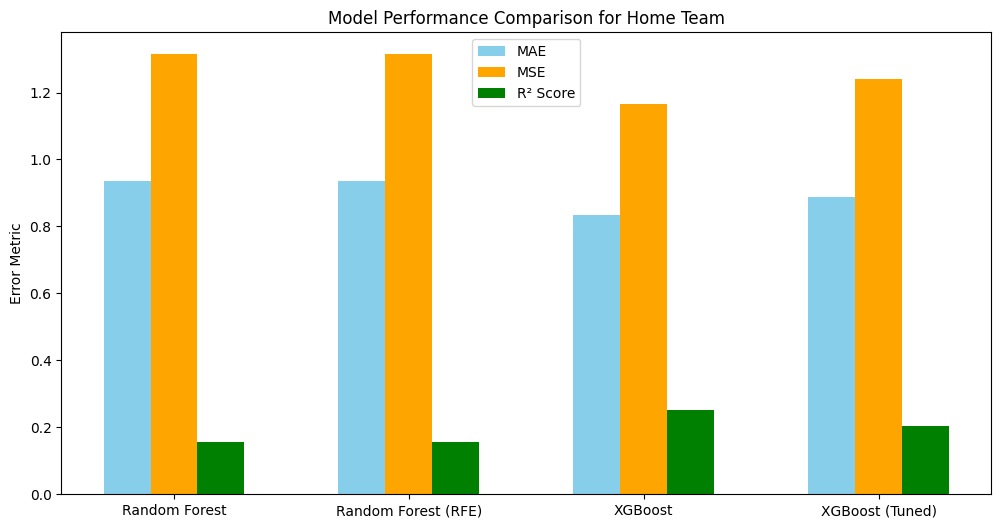

In [18]:
# Define error metrics for comparison
models = ['Random Forest', 'Random Forest (RFE)', 'XGBoost', 'XGBoost (Tuned)']
mae = [
    mean_absolute_error(y_test_home, rf_home.predict(X_test_home)),
    mean_absolute_error(y_test_home, y_pred_home_rfe),
    mean_absolute_error(y_test_home, y_pred_home_xgb),
    mean_absolute_error(y_test_home, y_pred_home_optuna)
]
mse = [
    mean_squared_error(y_test_home, rf_home.predict(X_test_home)),
    mean_squared_error(y_test_home, y_pred_home_rfe),
    mean_squared_error(y_test_home, y_pred_home_xgb),
    mean_squared_error(y_test_home, y_pred_home_optuna)
]
r2 = [
    r2_score(y_test_home, rf_home.predict(X_test_home)),
    r2_score(y_test_home, y_pred_home_rfe),
    r2_score(y_test_home, y_pred_home_xgb),
    r2_score(y_test_home, y_pred_home_optuna)
]

x = np.arange(len(models))

# Plot Comparison of Metrics
plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, mae, 0.2, label='MAE', color='skyblue')
plt.bar(x, mse, 0.2, label='MSE', color='orange')
plt.bar(x + 0.2, r2, 0.2, label='R² Score', color='green')

plt.xticks(x, models)
plt.ylabel('Error Metric')
plt.title('Model Performance Comparison for Home Team')
plt.legend()
plt.show()


#### Vizualization for Tuning

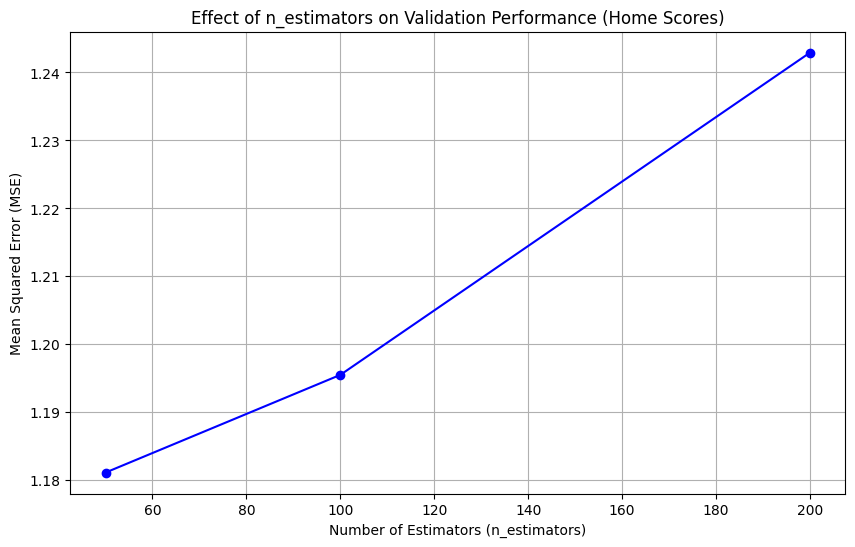

In [49]:
# Filter results for fixed values of other hyperparameters
fixed_params = (grid_search_home.cv_results_['param_max_depth'] == 3) & \
               (grid_search_home.cv_results_['param_learning_rate'] == 0.1) & \
               (grid_search_home.cv_results_['param_subsample'] == 1.0) & \
               (grid_search_home.cv_results_['param_min_child_weight'] == 1)

n_estimators = grid_search_home.cv_results_['param_n_estimators'][fixed_params]
mean_test_score = -grid_search_home.cv_results_['mean_test_score'][fixed_params]  # Convert to positive MSE

plt.figure(figsize=(10, 6))
plt.plot(n_estimators, mean_test_score, marker='o', color='blue')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Effect of n_estimators on Validation Performance (Home Scores)')
plt.grid(True)
plt.show()


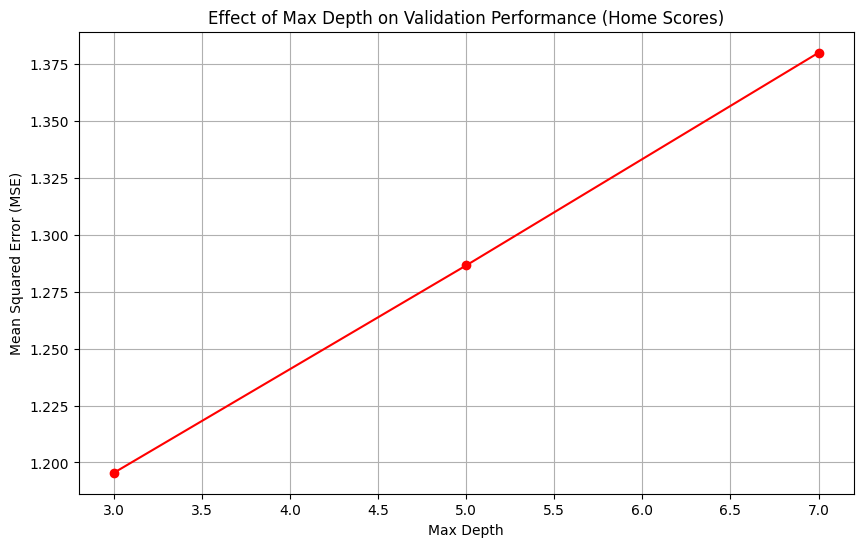

In [50]:
# Filter results for fixed values of other hyperparameters
fixed_params = (grid_search_home.cv_results_['param_n_estimators'] == 100) & \
               (grid_search_home.cv_results_['param_learning_rate'] == 0.1) & \
               (grid_search_home.cv_results_['param_subsample'] == 1.0) & \
               (grid_search_home.cv_results_['param_min_child_weight'] == 1)

max_depth = grid_search_home.cv_results_['param_max_depth'][fixed_params]
mean_test_score = -grid_search_home.cv_results_['mean_test_score'][fixed_params]

plt.figure(figsize=(10, 6))
plt.plot(max_depth, mean_test_score, marker='o', color='red')
plt.xlabel('Max Depth')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Effect of Max Depth on Validation Performance (Home Scores)')
plt.grid(True)
plt.show()


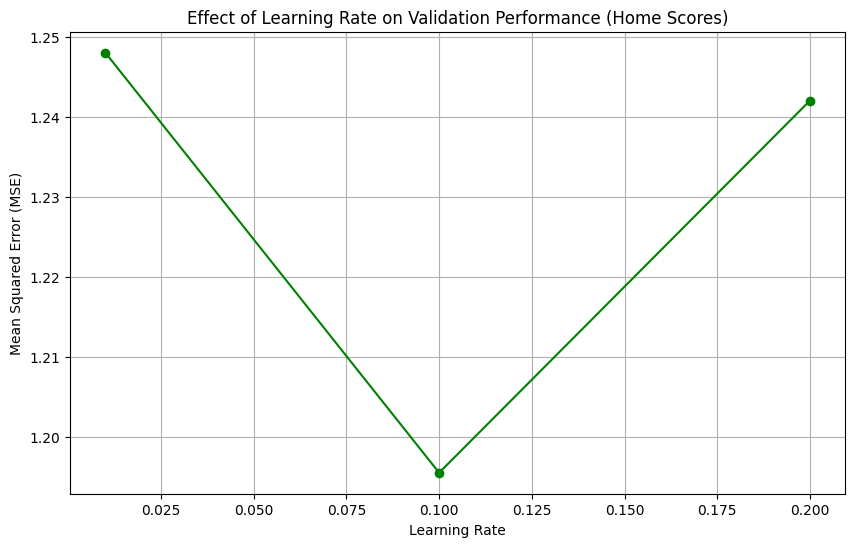

In [51]:
# Effect of learning_rate
fixed_params = (grid_search_home.cv_results_['param_n_estimators'] == 100) & \
               (grid_search_home.cv_results_['param_max_depth'] == 3) & \
               (grid_search_home.cv_results_['param_subsample'] == 1.0) & \
               (grid_search_home.cv_results_['param_min_child_weight'] == 1)

learning_rate = grid_search_home.cv_results_['param_learning_rate'][fixed_params]
mean_test_score = -grid_search_home.cv_results_['mean_test_score'][fixed_params]

plt.figure(figsize=(10, 6))
plt.plot(learning_rate, mean_test_score, marker='o', color='green')
plt.xlabel('Learning Rate')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Effect of Learning Rate on Validation Performance (Home Scores)')
plt.grid(True)
plt.show()


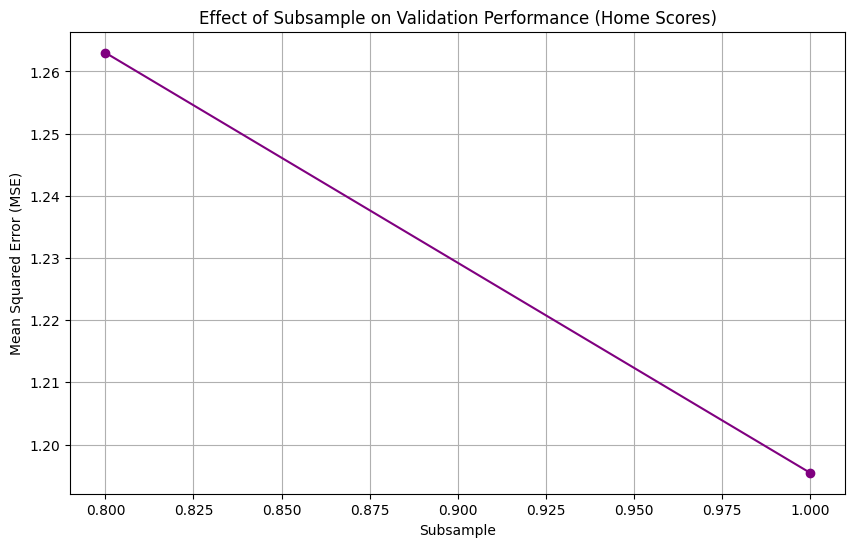

In [53]:
# Effect of subsample
fixed_params = (grid_search_home.cv_results_['param_n_estimators'] == 100) & \
               (grid_search_home.cv_results_['param_max_depth'] == 3) & \
               (grid_search_home.cv_results_['param_learning_rate'] == 0.1) & \
               (grid_search_home.cv_results_['param_min_child_weight'] == 1)

subsample = grid_search_home.cv_results_['param_subsample'][fixed_params]
mean_test_score = -grid_search_home.cv_results_['mean_test_score'][fixed_params]

plt.figure(figsize=(10, 6))
plt.plot(subsample, mean_test_score, marker='o', color='purple')
plt.xlabel('Subsample')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Effect of Subsample on Validation Performance (Home Scores)')
plt.grid(True)
plt.show()


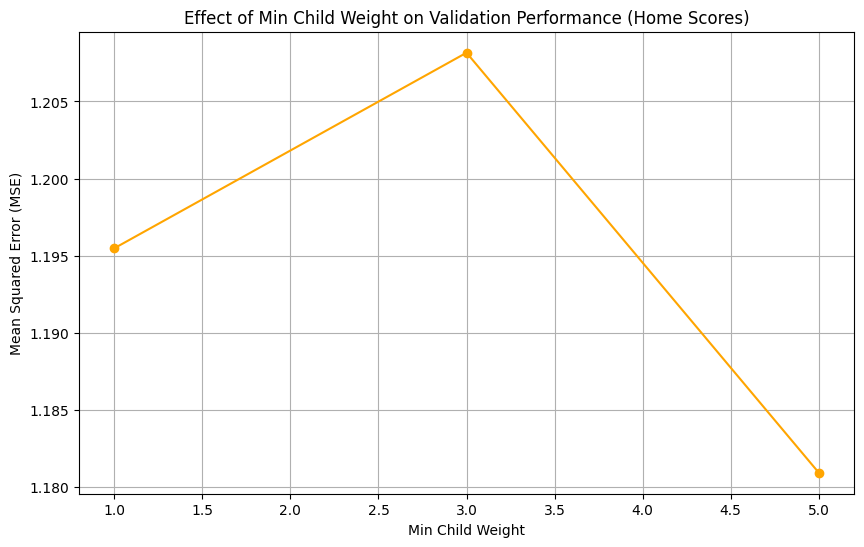

In [54]:
# Effect of min_child_weight
fixed_params = (grid_search_home.cv_results_['param_n_estimators'] == 100) & \
               (grid_search_home.cv_results_['param_max_depth'] == 3) & \
               (grid_search_home.cv_results_['param_learning_rate'] == 0.1) & \
               (grid_search_home.cv_results_['param_subsample'] == 1.0)

min_child_weight = grid_search_home.cv_results_['param_min_child_weight'][fixed_params]
mean_test_score = -grid_search_home.cv_results_['mean_test_score'][fixed_params]

plt.figure(figsize=(10, 6))
plt.plot(min_child_weight, mean_test_score, marker='o', color='orange')
plt.xlabel('Min Child Weight')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Effect of Min Child Weight on Validation Performance (Home Scores)')
plt.grid(True)
plt.show()


C:\Users\sande\AppData\Local\Temp\ipykernel_26756\1686706013.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  parallel_plot_df['mean_test_score'] = -parallel_plot_df['mean_test_score']  # Convert to positive MSE


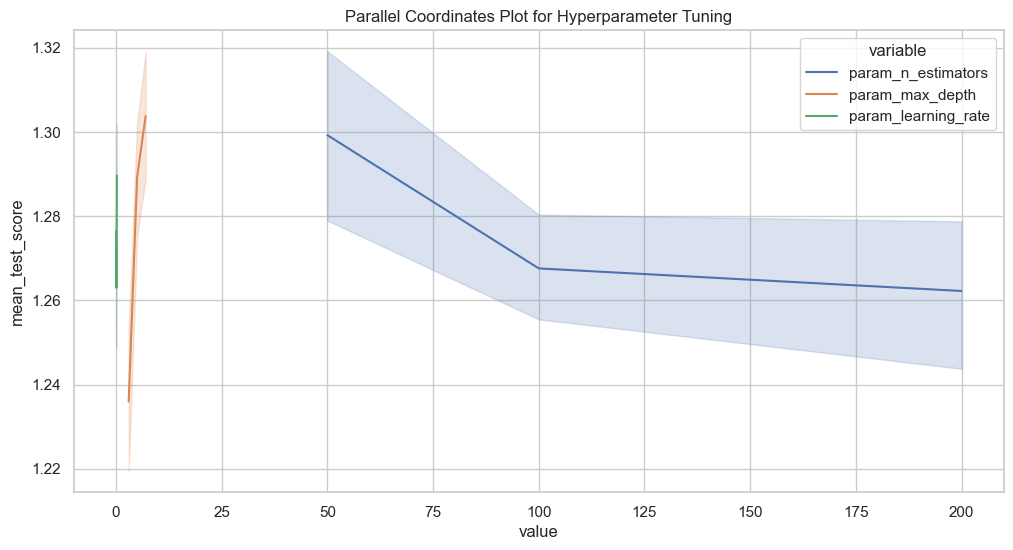

In [58]:
from pandas import DataFrame
import seaborn as sns

# Convert cv_results_ to DataFrame
results_df = DataFrame(grid_search_home.cv_results_)

# Select relevant columns
params = ['param_n_estimators', 'param_max_depth', 'param_learning_rate', 'mean_test_score']
sns.set(style="whitegrid")
parallel_plot_df = results_df[params]
parallel_plot_df['mean_test_score'] = -parallel_plot_df['mean_test_score']  # Convert to positive MSE

# Parallel coordinates plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=parallel_plot_df.melt(id_vars='mean_test_score'), x='value', y='mean_test_score', hue='variable')
plt.title('Parallel Coordinates Plot for Hyperparameter Tuning')
plt.show()


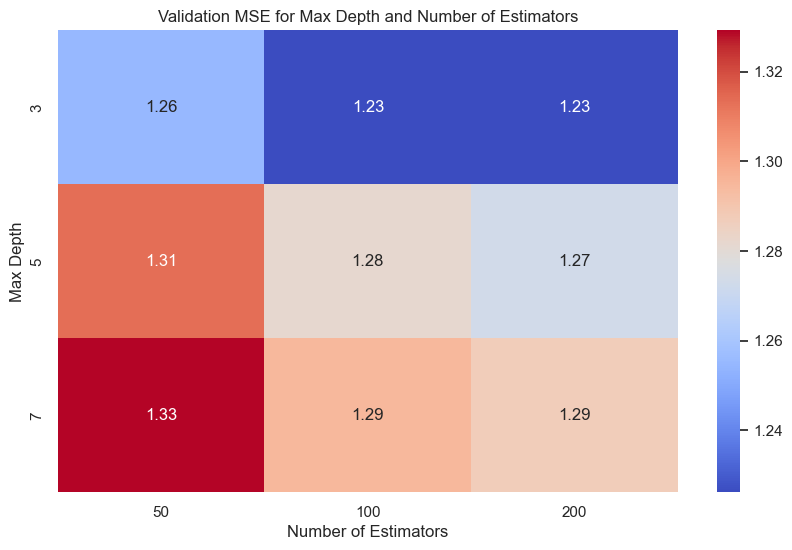

In [59]:
# Example: Heatmap for max_depth and n_estimators
heatmap_data = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators',
    aggfunc='mean'
)
plt.figure(figsize=(10, 6))
sns.heatmap(-heatmap_data, annot=True, fmt=".2f", cmap="coolwarm")  # Convert to positive MSE
plt.title('Validation MSE for Max Depth and Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Max Depth')
plt.show()
